In [1]:
import sys
sys.path.append('../')

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from helpers.cm26 import DatasetCM26, read_datasets
from helpers.selectors import *
from helpers.operators import Coarsen, Filtering, Subsampling, CoarsenKochkov, CoarsenWeighted, CoarsenKochkovMinMax
from helpers.state_functions import *

#import hvplot.xarray
import hvplot
import cmocean

%load_ext autoreload
%autoreload 3

# Reading data on Greene

In [2]:
ds = read_datasets(['test'], [4], subfilter='subfilter-large')['test-4'].select2d(time=0,zl=0)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4


In [3]:
SGS_KE = - 0.5 * ds.nanvar(ds.data.Txx + ds.data.Tyy)
Tdd = 0.5 * ds.nanvar(ds.data.Txx - ds.data.Tyy)
Txy = ds.nanvar(ds.data.Txy)

In [4]:
EXP1 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP1/model/Tall.nc')
EXP2 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/EXP2/model/Tall.nc')
EXP3 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/Collocated-NN-params/hdn-32-32/model/Tall.nc')
EXP4 = import_ANN('/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter/FGR3/Collocated-NN-params/hdn-128-128-128/model/Tall.nc')

In [7]:
ann1 = ds.state.ANN(ann_Tall=EXP1,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
ann2 = ds.state.ANN(ann_Tall=EXP2,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
ann3 = ds.state.ANN(ann_Tall=EXP3,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])
ann4 = ds.state.ANN(ann_Tall=EXP4,gradient_features=['sh_xy', 'sh_xx', 'rel_vort'])

In [8]:
SGS_KEf = lambda x: - 0.5 * ds.nanvar(x['Txx'] + x['Tyy'])

In [9]:
Tddf = lambda x: 0.5 * ds.nanvar(x['Txx'] - x['Tyy'])

In [10]:
Txyf = lambda x: ds.nanvar(x['Txy'])

Correlation: 0.917830876976284
Relative Error: 0.3016493556528939
R2 =  0.8722597948401845
R2 max =  0.8746149141909721
Optinal scaling: 1.0547318425754622
Nans [test/control]: [7733, 7733]


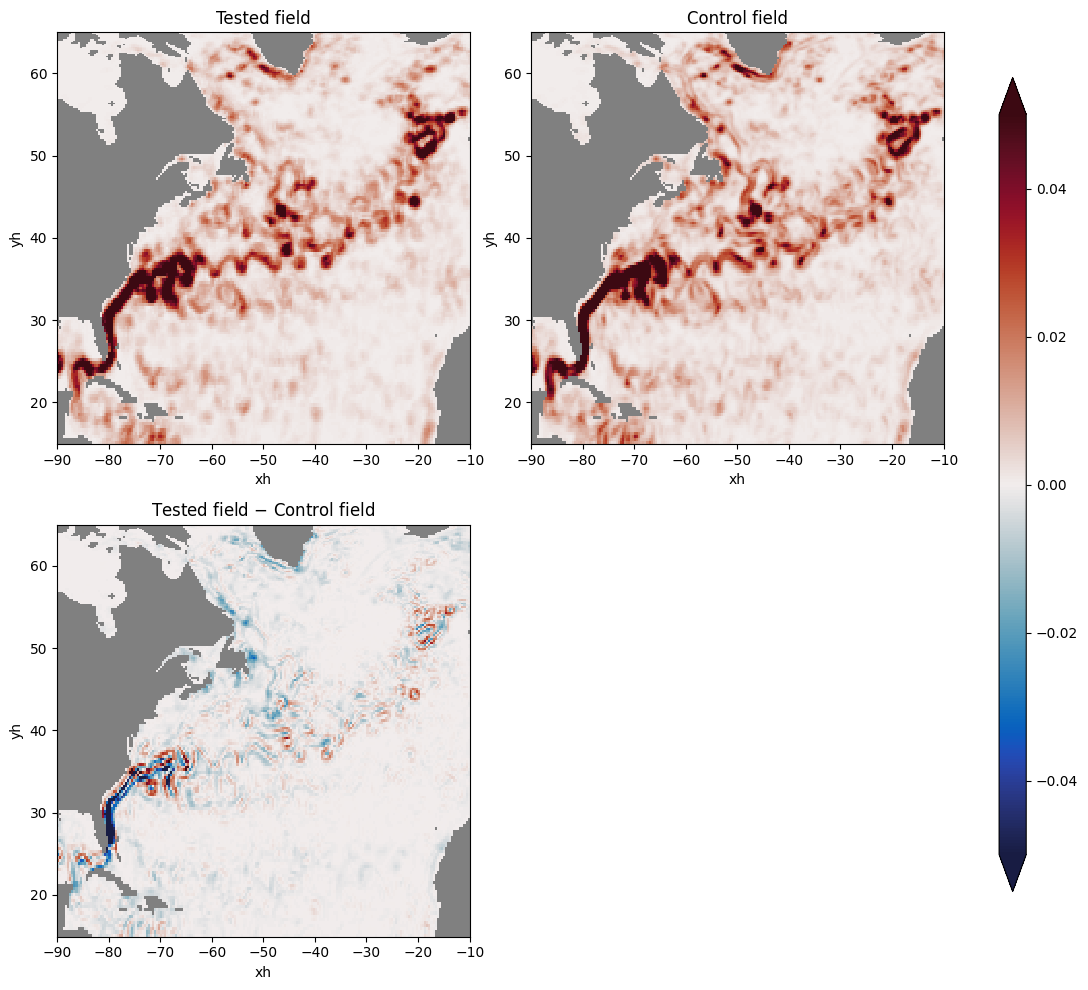

In [16]:
compare(SGS_KEf(ann1), SGS_KE, selector=select_NA, vmin=-0.05, vmax=0.05);

Correlation: 0.9464586020567106
Relative Error: 0.2430176709755141
R2 =  0.9145189514469864
R2 max =  0.9172328107996228
Optinal scaling: 1.057523302842659
Nans [test/control]: [7733, 7733]


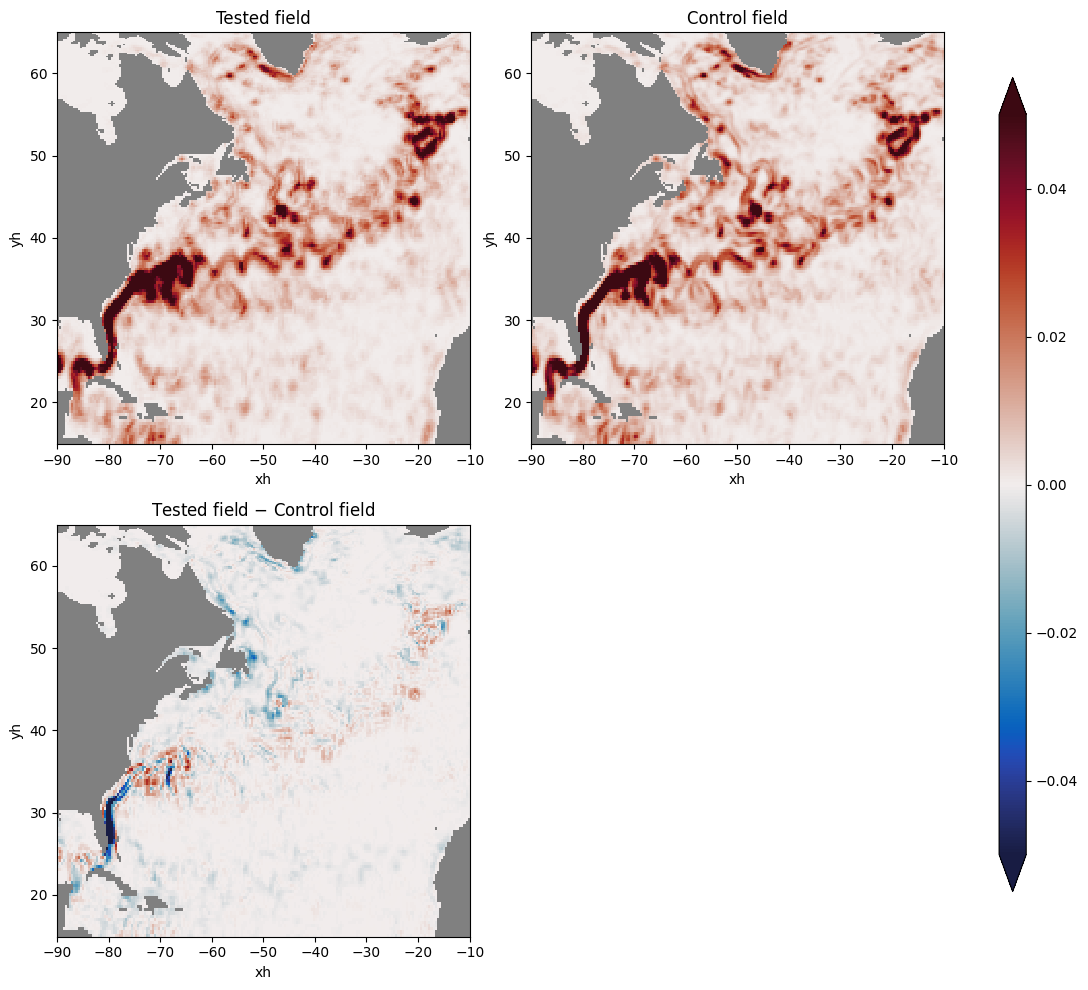

In [17]:
compare(SGS_KEf(ann2), SGS_KE, selector=select_NA, vmin=-0.05, vmax=0.05);

Correlation: 0.9394958059312044
Relative Error: 0.2596011722603097
R2 =  0.9034161090994433
R2 max =  0.9069841819700064
Optinal scaling: 1.0669188354009744
Nans [test/control]: [7733, 7733]


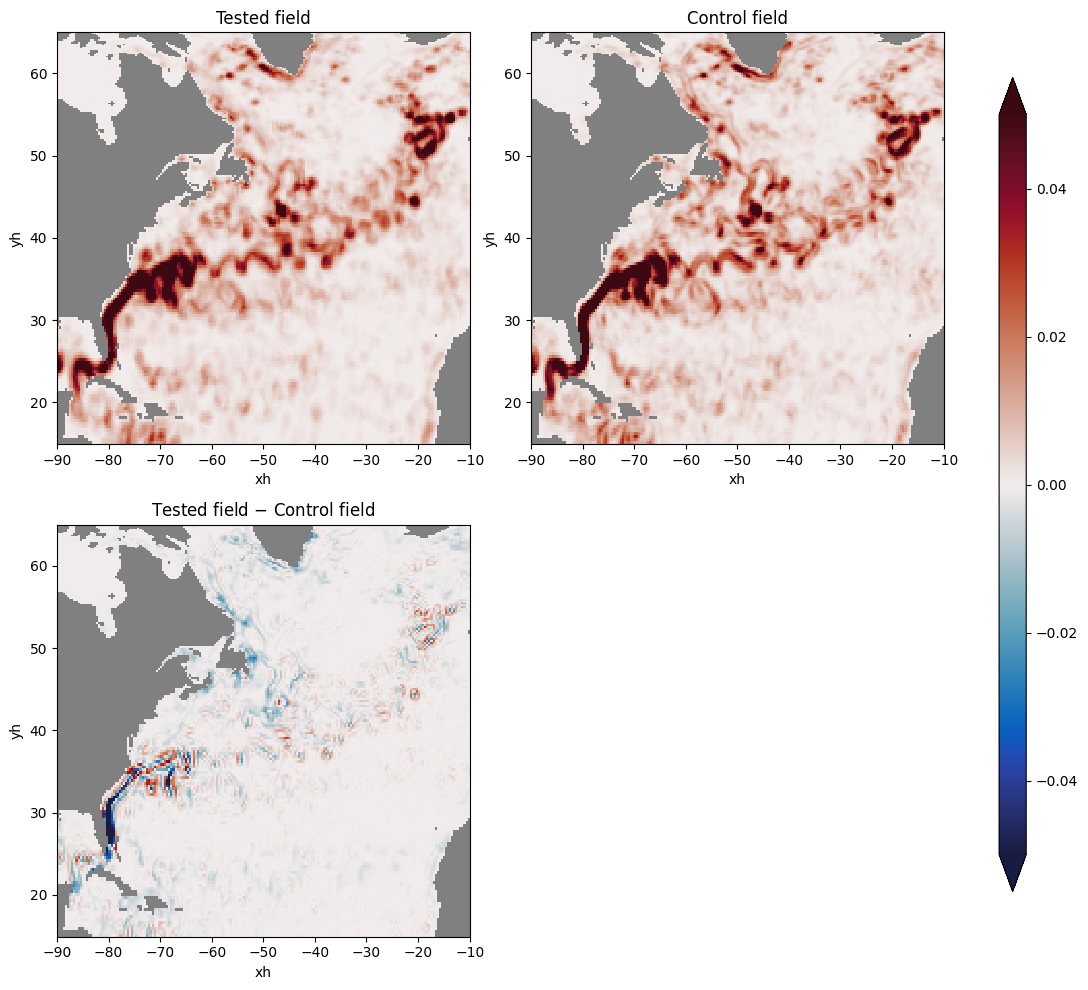

In [18]:
compare(SGS_KEf(ann3), SGS_KE, selector=select_NA, vmin=-0.05, vmax=0.05);

Correlation: 0.9073327134825127
Relative Error: 0.3216212801804741
R2 =  0.8590076608239763
R2 max =  0.8601188538630197
Optinal scaling: 1.0372831711551753
Nans [test/control]: [7733, 7733]


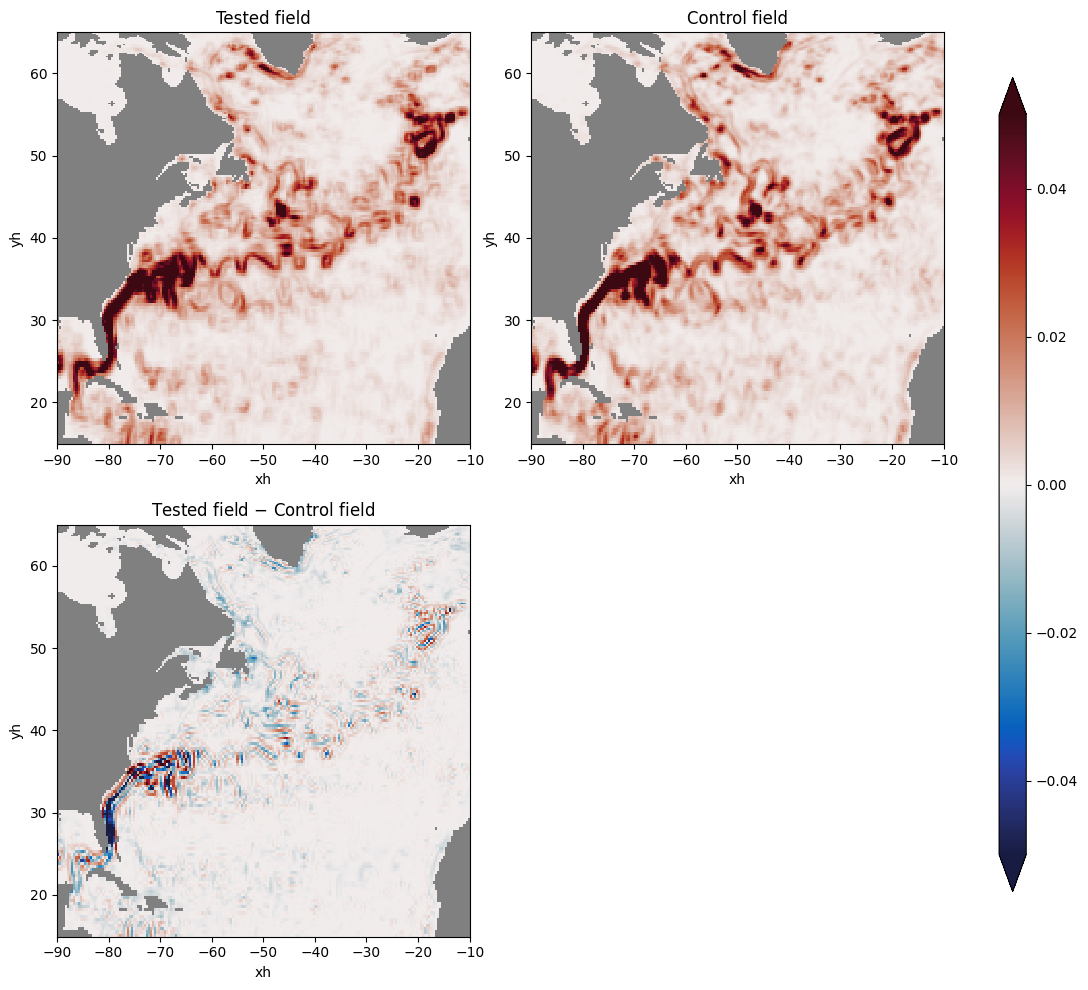

In [19]:
compare(SGS_KEf(ann4), SGS_KE, selector=select_NA, vmin=-0.05, vmax=0.05);

Correlation: 0.8620941730811904
Relative Error: 0.5330487539247837
R2 =  0.7173424531320451
R2 max =  0.7428223073464182
Optinal scaling: 1.2273046855210796
Nans [test/control]: [7733, 7733]


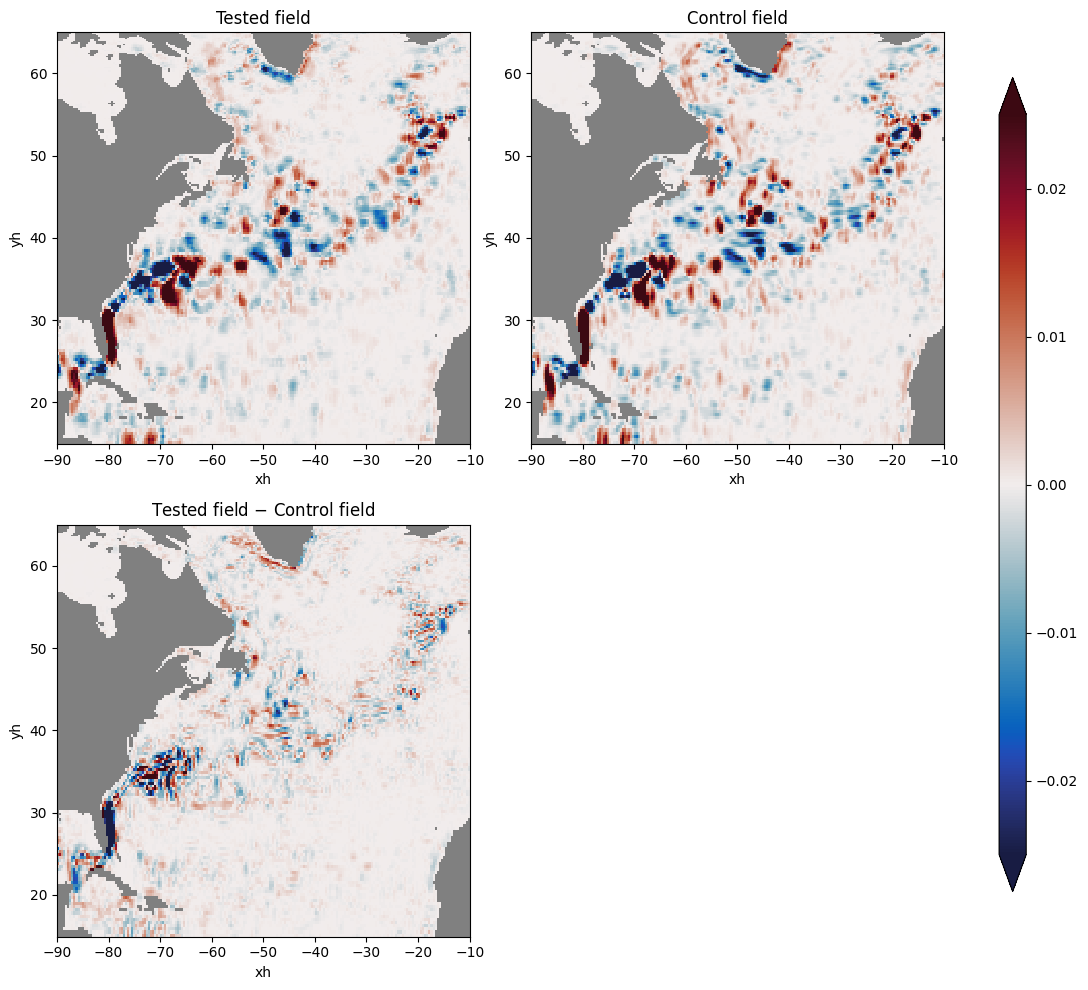

In [26]:
compare(Tddf(ann1), Tdd, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.9034504918842087
Relative Error: 0.4602713129084732
R2 =  0.7574397797969046
R2 max =  0.8160319614998655
Optinal scaling: 1.3660412843180896
Nans [test/control]: [7733, 7733]


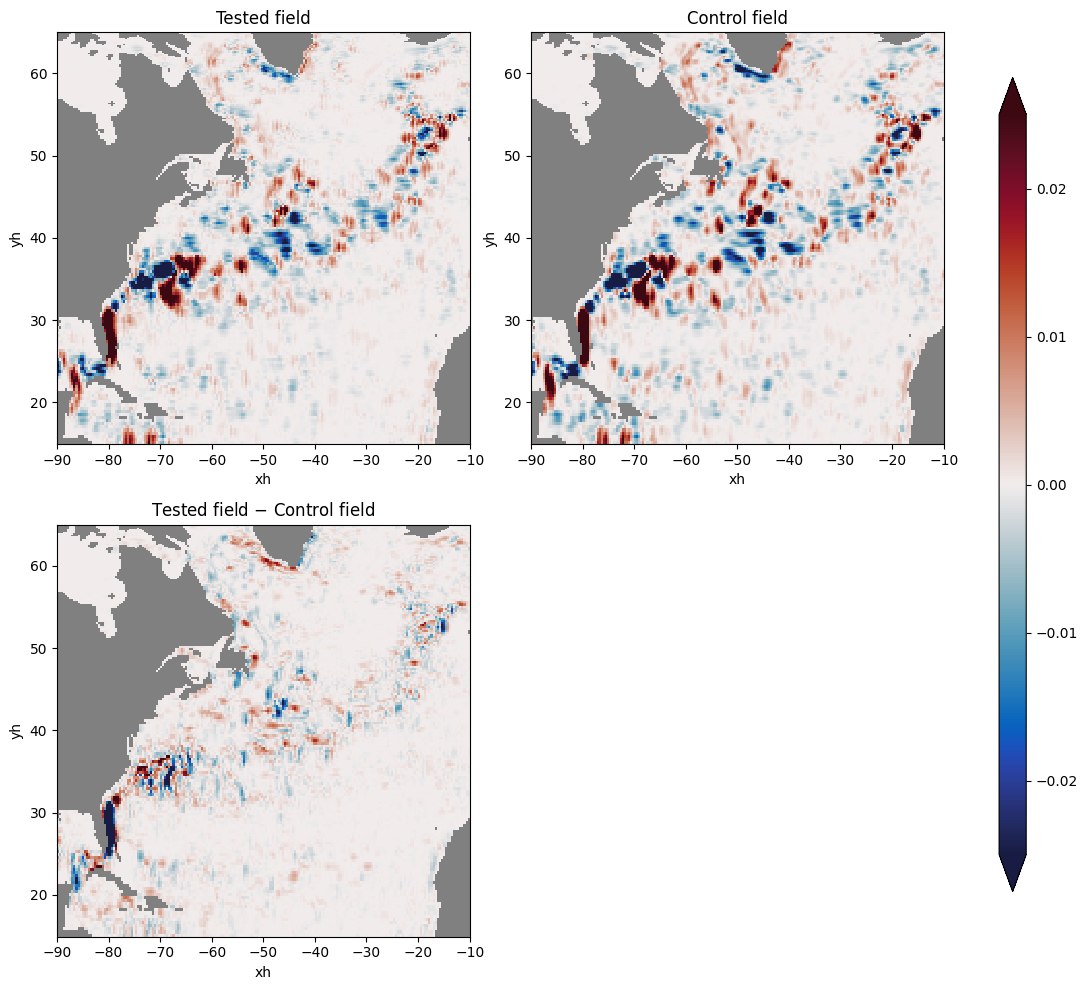

In [27]:
compare(Tddf(ann2), Tdd, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.8898747001261486
Relative Error: 0.47187687662523037
R2 =  0.7636864193639438
R2 max =  0.7911134050476507
Optinal scaling: 1.2287966635877547
Nans [test/control]: [7733, 7733]


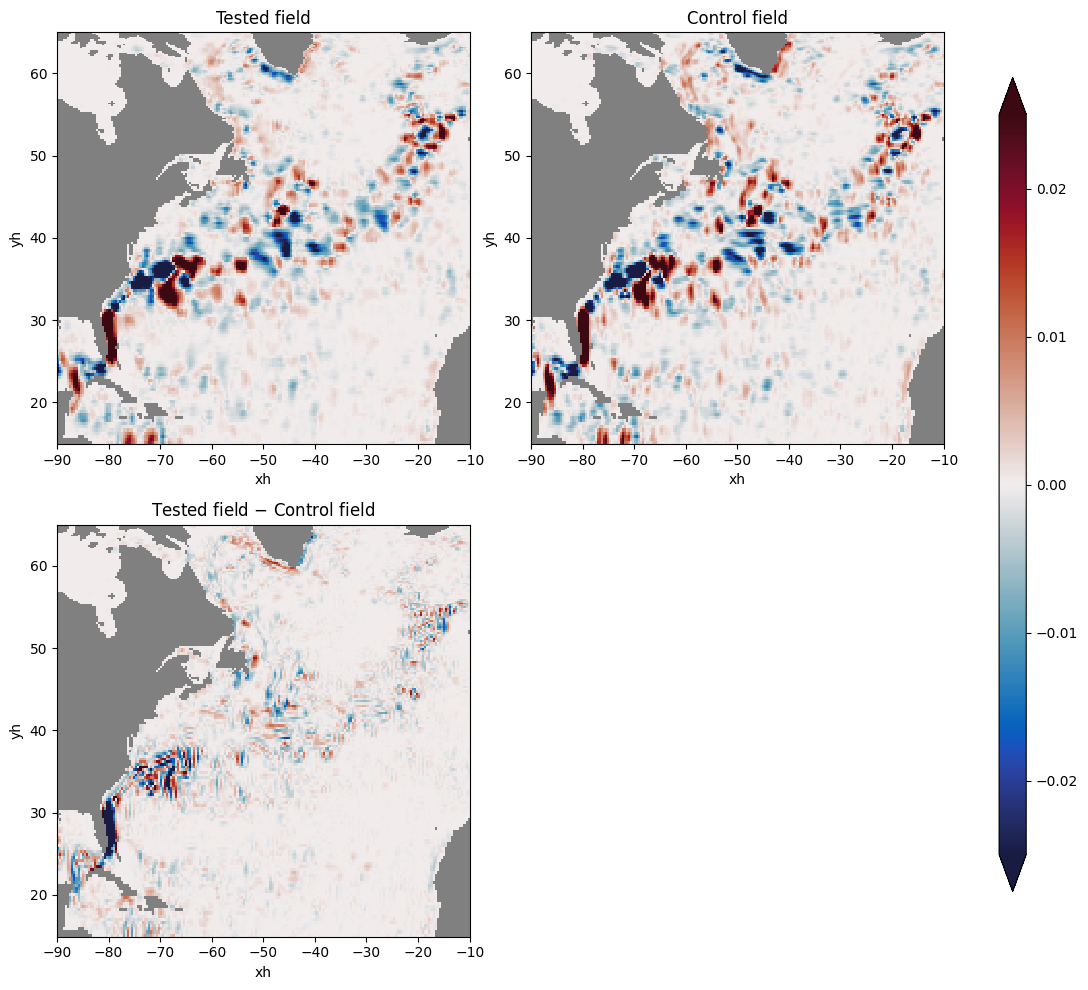

In [28]:
compare(Tddf(ann3), Tdd, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.8386229567571059
Relative Error: 0.6057612135539916
R2 =  0.7013390296477342
R2 max =  0.703096792498374
Optinal scaling: 1.0526319071780952
Nans [test/control]: [7733, 7733]


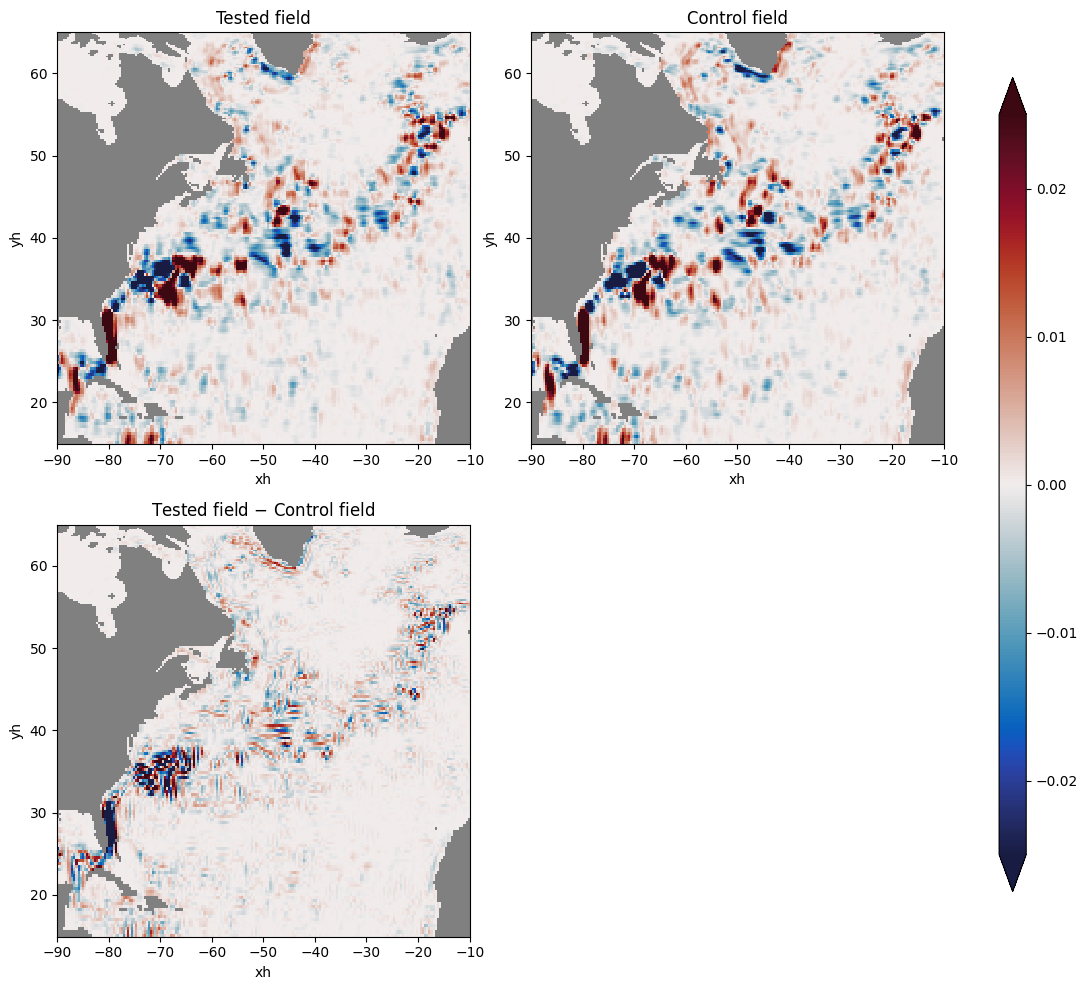

In [29]:
compare(Tddf(ann4), Tdd, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.8886075152133965
Relative Error: 0.525119236983685
R2 =  0.7862983995442989
R2 max =  0.7901051060487565
Optinal scaling: 0.9350936258346366
Nans [test/control]: [7733, 7733]


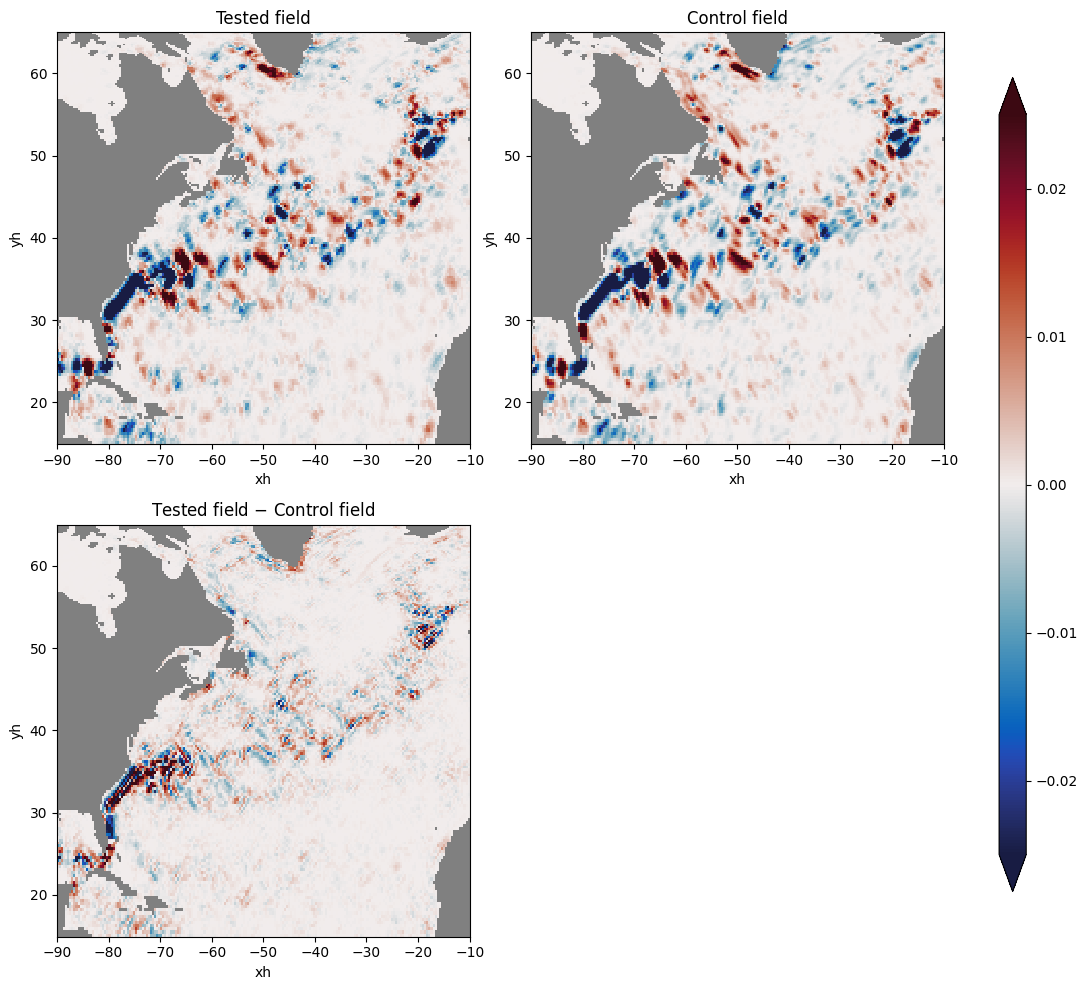

In [30]:
compare(Txyf(ann1), Txy, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.9326813928959737
Relative Error: 0.45526650608950714
R2 =  0.8700323875285809
R2 max =  0.870055974536798
Optinal scaling: 1.0052339548589735
Nans [test/control]: [7733, 7733]


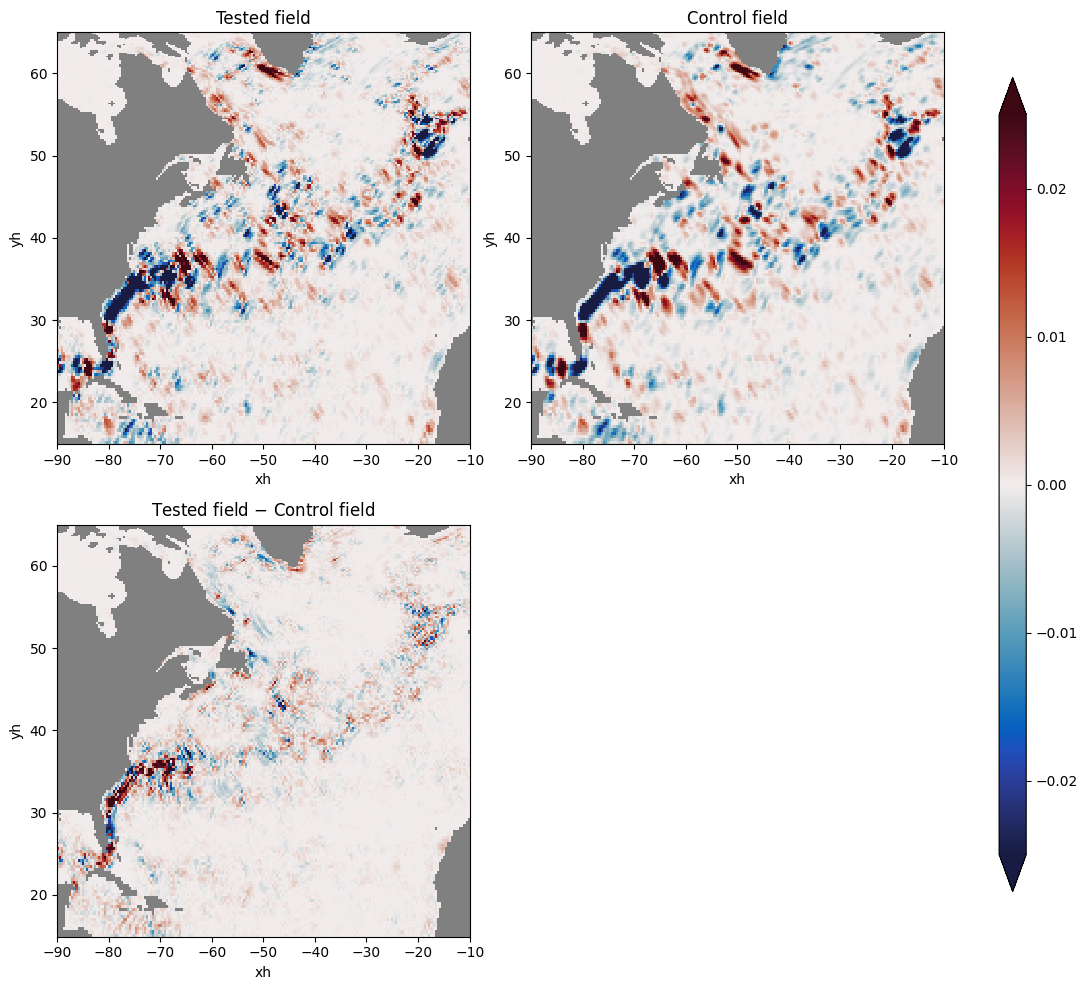

In [31]:
compare(Txyf(ann2), Txy, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.9301873310114186
Relative Error: 0.42808400555154236
R2 =  0.8648354724969356
R2 max =  0.8656732374129192
Optinal scaling: 1.0321076924383092
Nans [test/control]: [7733, 7733]


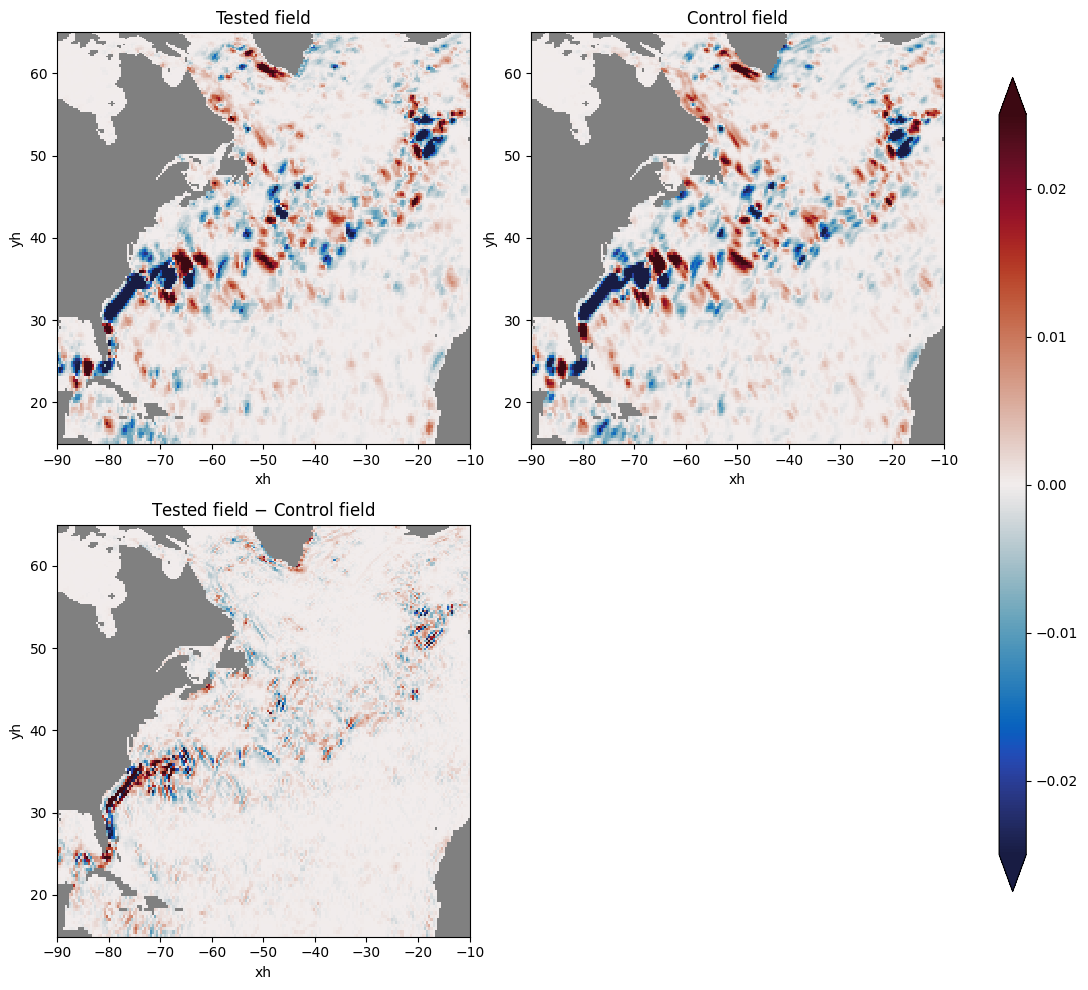

In [32]:
compare(Txyf(ann3), Txy, selector=select_NA, vmin=-0.025, vmax=0.025);

Correlation: 0.8490966844382455
Relative Error: 0.643017227648707
R2 =  0.7101591032769079
R2 max =  0.721775871135461
Optinal scaling: 0.8874178301956823
Nans [test/control]: [7733, 7733]


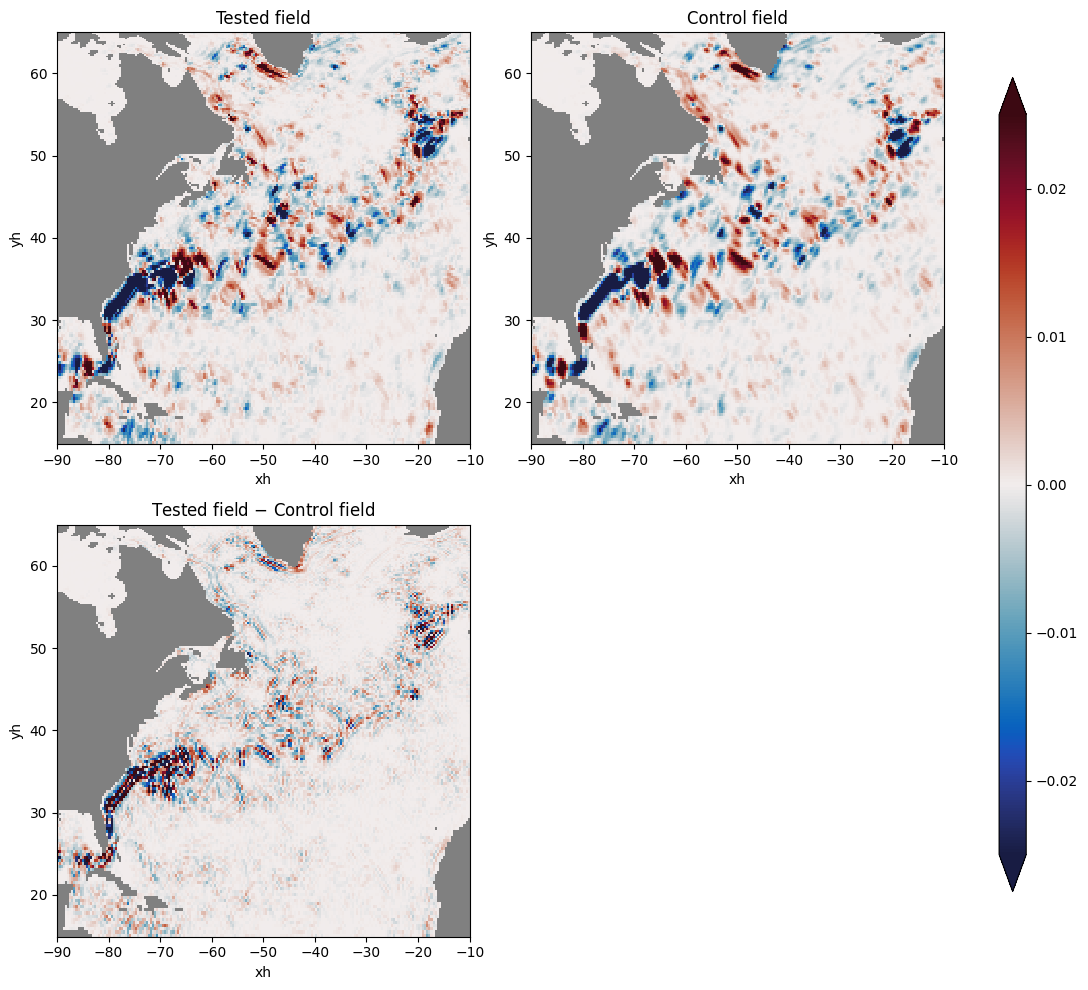

In [33]:
compare(Txyf(ann4), Txy, selector=select_NA, vmin=-0.025, vmax=0.025);

# Summary
* All four neural networks (600 params, 1800 params, 36000 params) are slightly different
* But predict subfilter fluxes with 0.8-0.9 correlation and 0.7-0.8 R-squared
* Big models do not seem to be superior in prediction of fluxes
* But they are superior in prediction of divergence of fluxes (I checked).
* Apparently, there are no overshoots in subfilter fluxes near the boundaries, and all models are able to predict them. Although, they are not trained directly on these fluxes.